In [57]:
%matplotlib inline

# Test YOLO on Tooth Detection Dataset

This notebook loads the fine-tuned PyTorch Lightning model from our training script and evaluates it on the test dataset.

In [58]:
from __future__ import annotations

import os
import sys
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import lightning as L
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Ensure project imports work from notebook location.
PROJECT_ROOT = Path('/work')
SCRIPTS_ROOT = PROJECT_ROOT / 'scripts'
for p in (PROJECT_ROOT, SCRIPTS_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import config
from detection_pipeline import (
    DetectionDownloadConfig,
    ToothDetectionDataset,
    AugmentedToothDetectionDataset,
    build_detection_records,
    build_detection_train_pipeline,
    load_or_download_detection_dataset,
    split_grouped_records
)

In [59]:
@dataclass
class TrainConfig:
    image_size: int = 640
    batch_size: int = 32
    num_workers: int = 0
    conf_threshold: float = 0.001
    iou_threshold: float = 0.6
    pretrained_weights: str = 'yolov5s.pt'
    experiment_name: str = 'label-loss-augmented'
    force_download: bool = False
    
    # Other parameters are ignored during testing but are kept for module loading compatibility
    max_epochs: int = 20
    lr: float = 0.00045636389024364654
    weight_decay: float = 0.000005312109908408371
    adamw_beta1: float = 0.9
    adamw_beta2: float = 0.999
    train_subset_size: int | None = None
    val_subset_size: int | None = None
    test_subset_size: int | None = None

cfg = TrainConfig()

# Inference/NMS settings used by both metric evaluation and visualization.
# Change these values here when you want to make YOLO predictions more or less strict.
INFERENCE_CONF_THRESHOLD = 0.22
INFERENCE_IOU_THRESHOLD = 0.45
INFERENCE_MAX_DETECTIONS = 32

cfg.conf_threshold = INFERENCE_CONF_THRESHOLD
cfg.iou_threshold = INFERENCE_IOU_THRESHOLD

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print(f'Inference thresholds: conf={cfg.conf_threshold}, iou={cfg.iou_threshold}')



Device: cuda
Inference thresholds: conf=0.22, iou=0.45


In [60]:
# Clone YOLOv5 if missing and put it first in import order for yolo-specific utils.
YOLOV5_DIR = PROJECT_ROOT / 'external' / 'yolov5'
YOLOV5_DIR.parent.mkdir(parents=True, exist_ok=True)

if not YOLOV5_DIR.exists():
    subprocess.run([
        'git', 'clone', '--depth', '1', 'https://github.com/ultralytics/yolov5.git', str(YOLOV5_DIR)
    ], check=True)

if str(YOLOV5_DIR) not in sys.path:
    sys.path.insert(0, str(YOLOV5_DIR))

from models.yolo import Model
from utils.loss import ComputeLoss
from utils.general import intersect_dicts, non_max_suppression

print('YOLOv5 code loaded from:', YOLOV5_DIR)

YOLOv5 code loaded from: /work/external/yolov5


In [61]:
class YoloTargetAdapterDataset(Dataset):
    """Wraps ToothDetectionDataset to emit labels compatible with YOLOv5 training loss."""

    def __init__(self, base_dataset: Dataset):
        self.base_dataset = base_dataset

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, index: int):
        image, target = self.base_dataset[index]
        return image, target


def yolo_collate_fn(batch: list[tuple[torch.Tensor, dict[str, Any]]]):
    images = []
    yolo_targets = []
    metric_targets = []

    for i, (img, tgt) in enumerate(batch):
        images.append(img.float())

        boxes_xyxy = tgt['boxes'].float()
        labels_one_based = tgt['labels'].long()

        # TorchMetrics expects class IDs starting at 0.
        metric_targets.append({
            'boxes': boxes_xyxy,
            'labels': (labels_one_based - 1).clamp_min(0),
        })

        if boxes_xyxy.numel() == 0:
            continue

        _, h, w = img.shape
        x1, y1, x2, y2 = boxes_xyxy[:, 0], boxes_xyxy[:, 1], boxes_xyxy[:, 2], boxes_xyxy[:, 3]

        cx = ((x1 + x2) * 0.5) / w
        cy = ((y1 + y2) * 0.5) / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        cls = (labels_one_based - 1).float().clamp_min(0)
        batch_idx = torch.full((boxes_xyxy.shape[0],), float(i), dtype=torch.float32)

        packed = torch.stack([batch_idx, cls, cx, cy, bw, bh], dim=1)
        yolo_targets.append(packed)

    images = torch.stack(images, dim=0)
    if yolo_targets:
        yolo_targets = torch.cat(yolo_targets, dim=0)
    else:
        yolo_targets = torch.zeros((0, 6), dtype=torch.float32)

    return images, yolo_targets, metric_targets


class ToothDetectionDataModule(L.LightningDataModule):
    def __init__(self, cfg: TrainConfig):
        super().__init__()
        self.cfg = cfg
        self.train_ds = None
        self.val_ds = None
        self.test_ds = None

    def setup(self, stage: str | None = None):
        try:
            from dotenv import load_dotenv
            env_path = PROJECT_ROOT / '.env'
            if load_dotenv is not None and env_path.exists():
                load_dotenv(env_path, override=True)
        except ImportError:
            pass
            
        _, coco_data, image_dirs = load_or_download_detection_dataset(
            DetectionDownloadConfig(api_key=os.getenv('ROBOFLOW_API_KEY')),
            force_download=self.cfg.force_download,
        )
        records, _ = build_detection_records(coco_data, image_dirs)

        train_rec, val_rec, test_rec = split_grouped_records(
            records,
            train_size=config.TRAIN_RATIO,
            val_size=config.VAL_RATIO,
            test_size=config.TEST_RATIO,
            random_state=42
        )

        if self.cfg.train_subset_size is not None:
            train_rec = train_rec[: self.cfg.train_subset_size]
        if self.cfg.val_subset_size is not None:
            val_rec = val_rec[: self.cfg.val_subset_size]
        if self.cfg.test_subset_size is not None:
            test_rec = test_rec[: self.cfg.test_subset_size]

        base_train = ToothDetectionDataset(
            train_rec, image_size=self.cfg.image_size, output_channels=3
        )
        aug_train = AugmentedToothDetectionDataset(base_train, build_detection_train_pipeline())
        
        base_val = ToothDetectionDataset(
            val_rec, image_size=self.cfg.image_size, output_channels=3
        )
        base_test = ToothDetectionDataset(
            test_rec, image_size=self.cfg.image_size, output_channels=3
        )

        self.train_ds = YoloTargetAdapterDataset(aug_train)
        self.val_ds = YoloTargetAdapterDataset(base_val)
        self.test_ds = YoloTargetAdapterDataset(base_test)

        print(f'Train/Val/Test sizes: {len(self.train_ds)}, {len(self.val_ds)}, {len(self.test_ds)}')

    def _loader_kwargs(self) -> dict[str, Any]:
        num_workers = int(self.cfg.num_workers)
        kwargs: dict[str, Any] = {
            'num_workers': num_workers,
            'pin_memory': torch.cuda.is_available(),
            'collate_fn': yolo_collate_fn,
        }
        if num_workers > 0:
            kwargs['persistent_workers'] = True
            kwargs['prefetch_factor'] = 2
        return kwargs

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            drop_last=True,
            **self._loader_kwargs(),
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.cfg.batch_size,
            shuffle=False,
            **self._loader_kwargs(),
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.cfg.batch_size,
            shuffle=False,
            **self._loader_kwargs(),
        )

In [62]:
class LitYOLOv5(L.LightningModule):
    def __init__(self, cfg: TrainConfig, num_classes: int = 32):
        super().__init__()
        self.save_hyperparameters(ignore=["cfg"])

        self.cfg = cfg
        self.num_classes = num_classes
        self.compute_loss = None

        # When testing, we can initialize with either base weights or just state structure
        ckpt_path = Path(cfg.pretrained_weights)
        if ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location="cpu")
            yolo_cfg = ckpt["model"].yaml
        else:
            # Fallback configuration
            yolo_cfg = YOLOV5_DIR / "models" / "yolov5s.yaml"

        self.model = Model(yolo_cfg, ch=3, nc=num_classes).float()
        self.model.hyp = {
            "box": 0.05, "cls": 0.3, "obj": 0.7,
            "cls_pw": 1.0, "obj_pw": 1.0, "fl_gamma": 0.0,
            "label_smoothing": 0.0, "anchor_t": 4.0,
        }

        self.map_metric = MeanAveragePrecision(
            box_format="xyxy",
            class_metrics=False,
        )

    def on_train_start(self):
        pass # Ignored for testing

    def forward(self, x: torch.Tensor):
        return self.model(x)

    def training_step(self, batch, batch_idx: int):
        pass # Ignored for testing 

    def validation_step(self, batch, batch_idx: int):
        pass # Not using validation here

    def on_validation_epoch_end(self):
        pass # Not using validation here

    def test_step(self, batch, batch_idx: int):
        images, _, metric_targets = batch
        raw_output = self.model(images)
        preds = raw_output[0] if isinstance(raw_output, (tuple, list)) else raw_output

        nms_preds = non_max_suppression(
            preds,
            conf_thres=self.cfg.conf_threshold,
            iou_thres=self.cfg.iou_threshold,
            multi_label=False,
            max_det=INFERENCE_MAX_DETECTIONS,
        )

        metric_preds = []
        for det in nms_preds:
            if det is None or len(det) == 0:
                metric_preds.append({
                    "boxes": torch.zeros((0, 4), device=self.device),
                    "scores": torch.zeros((0,), device=self.device),
                    "labels": torch.zeros((0,), dtype=torch.long, device=self.device),
                })
                continue
            metric_preds.append({
                "boxes": det[:, :4],
                "scores": det[:, 4],
                "labels": det[:, 5].long(),
            })

        metric_targets_list = [
            {
                "boxes": target["boxes"].to(self.device),
                "labels": target["labels"].to(self.device),
            }
            for target in metric_targets
        ]

        self.map_metric.update(metric_preds, metric_targets_list)

    def on_test_epoch_end(self):
        metrics = self.map_metric.compute()

        self.log("test/map", metrics["map"], prog_bar=True)
        self.log("test/map_50", metrics["map_50"], prog_bar=True)
        self.log("test/map_75", metrics["map_75"])

        self.map_metric.reset()

    def configure_optimizers(self):
        pass


In [63]:
# Setup data module
datamodule = ToothDetectionDataModule(cfg)
datamodule.setup('test')

print(f'\nDataset sizes:')
print(f'  Test:  {len(datamodule.test_ds)} samples')

Train/Val/Test sizes: 528, 66, 67

Dataset sizes:
  Test:  67 samples


### Visualize Ground Truth and Model Predictions

The helper below can draw ground-truth boxes alone, or draw model predictions next to the annotations for qualitative inspection.


In [64]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

GT_COLOR = (255, 0, 0)      # red
PRED_COLOR = (0, 255, 0)    # green
TEXT_BG_COLOR = (0, 0, 0)


def tensor_to_uint8_image(img_tensor: torch.Tensor) -> np.ndarray:
    """
    Convert a CxHxW torch image tensor to an HxWxC uint8 numpy image.

    This is intentionally defensive because datasets may return images in [0, 1],
    [0, 255], or occasionally with small numerical overshoots after transforms.
    """
    img = img_tensor.detach().cpu().float()

    if img.ndim != 3:
        raise ValueError(f'Expected image tensor with shape CxHxW, got {tuple(img.shape)}')

    img = img.permute(1, 2, 0).numpy()

    if img.shape[2] == 1:
        img = np.repeat(img, 3, axis=2)

    if img.max() <= 1.5:
        img = img * 255.0

    return np.clip(img, 0, 255).astype(np.uint8)


def _as_numpy(x):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def draw_boxes_on_image(
    image_np: np.ndarray,
    boxes,
    labels=None,
    scores=None,
    *,
    color: tuple[int, int, int],
    prefix: str,
    width: int = 3,
) -> np.ndarray:
    """
    Draw xyxy boxes directly on a copy of the image using PIL.

    This avoids matplotlib patch-coordinate issues and works reliably in notebooks.
    """
    out = Image.fromarray(image_np.copy())
    draw = ImageDraw.Draw(out)

    boxes = _as_numpy(boxes)
    labels = _as_numpy(labels)
    scores = _as_numpy(scores)

    if boxes is None or len(boxes) == 0:
        return np.asarray(out)

    h, w = image_np.shape[:2]

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in box[:4]]

        # Keep drawing coordinates inside the image.
        x1 = max(0, min(w - 1, x1))
        y1 = max(0, min(h - 1, y1))
        x2 = max(0, min(w - 1, x2))
        y2 = max(0, min(h - 1, y2))

        if x2 <= x1 or y2 <= y1:
            continue

        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)

        text = prefix
        if labels is not None and i < len(labels):
            text += f' {int(labels[i])}'
        if scores is not None and i < len(scores):
            text += f' {float(scores[i]):.2f}'

        # Draw a small readable label background.
        text_x = int(x1)
        text_y = int(max(0, y1 - 14))
        text_bbox = draw.textbbox((text_x, text_y), text)
        draw.rectangle(text_bbox, fill=TEXT_BG_COLOR)
        draw.text((text_x, text_y), text, fill=color)

    return np.asarray(out)


@torch.no_grad()
def run_yolo_inference_on_images(
    model: LitYOLOv5,
    images: torch.Tensor,
    *,
    conf_threshold: float = INFERENCE_CONF_THRESHOLD,
    iou_threshold: float = INFERENCE_IOU_THRESHOLD,
    max_det: int = INFERENCE_MAX_DETECTIONS,
) -> list[dict[str, torch.Tensor]]:
    """
    Run YOLO inference on a batch of images and return boxes, scores and labels.

    Thresholds are passed explicitly so they can be changed in one place.
    """
    model.eval()
    device = next(model.parameters()).device
    images = images.to(device).float()

    raw_output = model.model(images)
    preds = raw_output[0] if isinstance(raw_output, (tuple, list)) else raw_output

    nms_preds = non_max_suppression(
        preds,
        conf_thres=conf_threshold,
        iou_thres=iou_threshold,
        multi_label=False,
        max_det=max_det,
    )

    results = []
    for det in nms_preds:
        if det is None or len(det) == 0:
            results.append({
                'boxes': torch.zeros((0, 4)),
                'scores': torch.zeros((0,)),
                'labels': torch.zeros((0,), dtype=torch.long),
            })
        else:
            results.append({
                'boxes': det[:, :4].detach().cpu(),
                'scores': det[:, 4].detach().cpu(),
                'labels': det[:, 5].long().detach().cpu(),
            })

    return results


@torch.no_grad()
def infer_samples_for_visualization(
    model: LitYOLOv5,
    dataset,
    sample_indices: list[int],
    *,
    conf_threshold: float = INFERENCE_CONF_THRESHOLD,
    iou_threshold: float = INFERENCE_IOU_THRESHOLD,
    max_det: int = INFERENCE_MAX_DETECTIONS,
) -> list[dict[str, Any]]:
    """
    Run model inference for selected dataset samples.

    The returned object is intentionally separate from plotting so visualization can be
    called only after inference has definitely happened.
    """
    if not sample_indices:
        raise ValueError('sample_indices must contain at least one index.')

    valid_indices = [idx for idx in sample_indices if 0 <= idx < len(dataset)]
    if not valid_indices:
        raise ValueError('No valid sample indices were provided.')

    images = []
    targets = []

    for idx in valid_indices:
        image, target = dataset[idx]
        images.append(image.float())
        targets.append(target)

    image_batch = torch.stack(images, dim=0)

    predictions = run_yolo_inference_on_images(
        model,
        image_batch,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold,
        max_det=max_det,
    )

    return [
        {
            'sample_idx': sample_idx,
            'image': image,
            'target': target,
            'prediction': prediction,
        }
        for sample_idx, image, target, prediction in zip(valid_indices, images, targets, predictions)
    ]


def visualize_inference_results(
    inference_results: list[dict[str, Any]],
    *,
    title: str = 'YOLO Predictions vs Ground Truth',
    conf_threshold: float = INFERENCE_CONF_THRESHOLD,
    iou_threshold: float = INFERENCE_IOU_THRESHOLD,
    max_det: int = INFERENCE_MAX_DETECTIONS,
):
    """
    Display ground-truth boxes and predicted boxes side by side.

    Left column: ground truth boxes in red.
    Right column: model predictions in green, with confidence scores.
    """
    if not inference_results:
        raise ValueError('No inference results were provided.')

    n = len(inference_results)
    fig, axes = plt.subplots(n, 2, figsize=(14, 6 * n), squeeze=False)
    fig.suptitle(
        f'{title}\nconf={conf_threshold}, iou={iou_threshold}, max_det={max_det}',
        fontsize=16,
    )

    for row, item in enumerate(inference_results):
        sample_idx = item['sample_idx']
        image_np = tensor_to_uint8_image(item['image'])
        target = item['target']
        prediction = item['prediction']

        gt_boxes = target.get('boxes', torch.zeros((0, 4))) if target is not None else torch.zeros((0, 4))
        gt_labels = target.get('labels', None) if target is not None else None

        gt_image = draw_boxes_on_image(
            image_np,
            gt_boxes,
            gt_labels,
            color=GT_COLOR,
            prefix='GT',
        )

        pred_image = draw_boxes_on_image(
            image_np,
            prediction['boxes'],
            prediction['labels'],
            prediction['scores'],
            color=PRED_COLOR,
            prefix='Pred',
        )

        axes[row, 0].imshow(gt_image)
        axes[row, 0].set_title(f'Sample {sample_idx}: ground truth')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(pred_image)
        axes[row, 1].set_title(f'Sample {sample_idx}: predictions ({len(prediction["boxes"])} boxes)')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()
    


In [65]:
# Load the final model
model_path = PROJECT_ROOT / 'output' / cfg.experiment_name / 'weights' / 'final_model.pt'

if not model_path.exists():
    raise FileNotFoundError(f"Model weights not found at {model_path}. Did you run the training script successfully?")

print(f"Loading weights from {model_path}...")

model_instance = LitYOLOv5(cfg=cfg, num_classes=32)

# Using strict=False as we saved raw YOLOv5 states. 
# They need to be loaded into the PyTorch Lightning wrapped YOLO model.
model_instance.model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=False)

print("Loaded model correctly!")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Overriding model.yaml nc=80 with nc=32

                 from  n    params  module                                  arguments                   

Loading weights from /work/output/label-loss-augmented/weights/final_model.pt...


Model summary: 214 layers, 7105933 parameters, 7105933 gradients, 16.2 GFLOPs

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loaded model correctly!


In [66]:
# Move the loaded model to the selected device.
model_instance = model_instance.to(DEVICE)
model_instance.eval()

print('Model is ready for testing and visualization.')


Model is ready for testing and visualization.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Running prediction on the test dataset...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Train/Val/Test sizes: 528, 66, 67


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/map          │    0.3964720368385315     │
│        test/map_50        │    0.5631855130195618     │
│        test/map_75        │    0.4718731641769409     │
└───────────────────────────┴───────────────────────────┘


--- Test Results ---
test/map: 0.3965
test/map_50: 0.5632
test/map_75: 0.4719


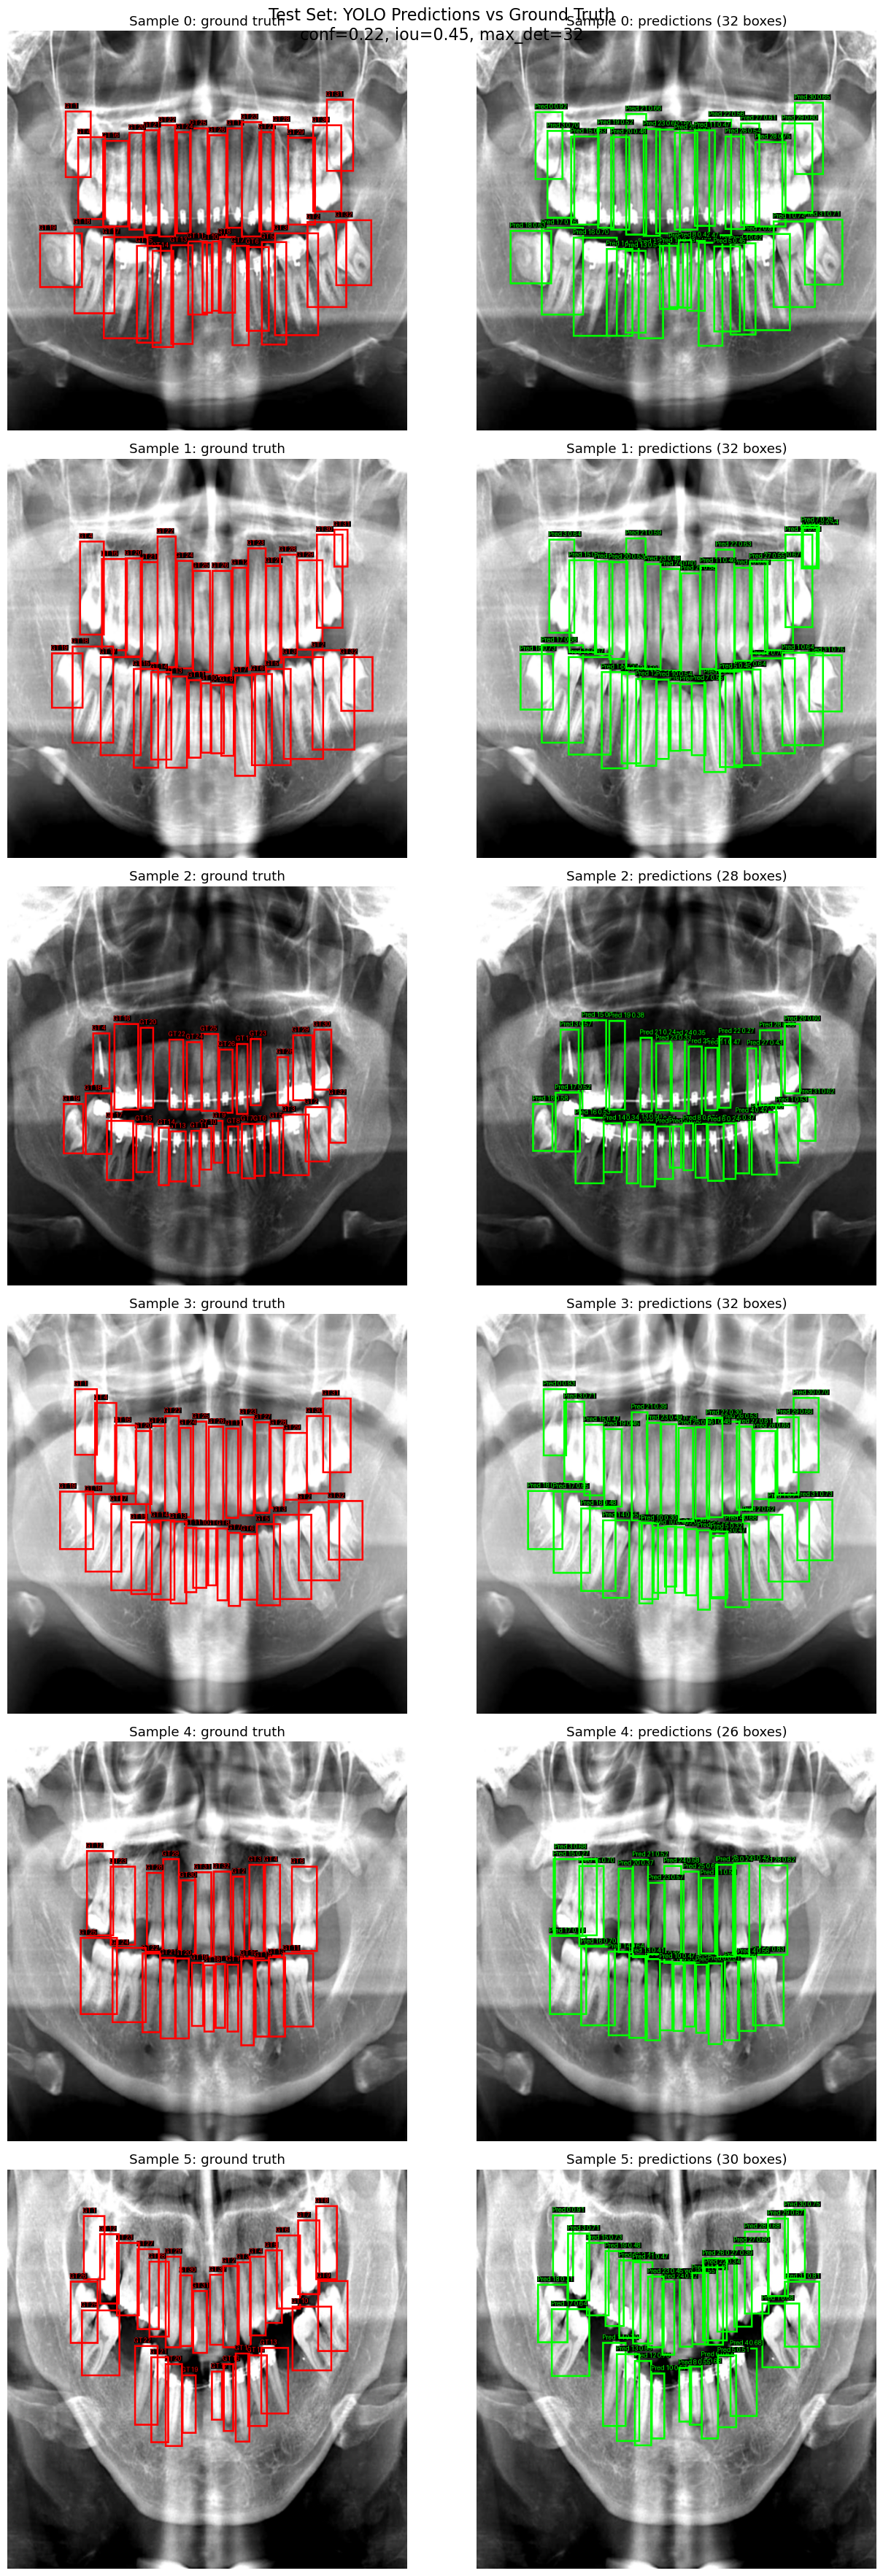

In [67]:
# Initialize lightning trainer
trainer = L.Trainer(
    accelerator='auto',
    devices=1,
    logger=False  # Typically disabled for pure testing.
)

# Run standard PyTorch Lightning testing script
print("Running prediction on the test dataset...")
test_results = trainer.test(model_instance, datamodule=datamodule)

print("\n--- Test Results ---")
for key, val in test_results[0].items():
    print(f"{key}: {val:.4f}")


# Run inference for visualization only after the model has been loaded and tested.
# Edit these values to control the visualization inference behavior.
VIS_CONF_THRESHOLD = INFERENCE_CONF_THRESHOLD
VIS_IOU_THRESHOLD = INFERENCE_IOU_THRESHOLD
VIS_MAX_DETECTIONS = INFERENCE_MAX_DETECTIONS
VIS_SAMPLE_INDICES = list(range(min(6, len(datamodule.test_ds))))

visualization_results = infer_samples_for_visualization(
    model_instance,
    datamodule.test_ds,
    VIS_SAMPLE_INDICES,
    conf_threshold=VIS_CONF_THRESHOLD,
    iou_threshold=VIS_IOU_THRESHOLD,
    max_det=VIS_MAX_DETECTIONS,
)

visualize_inference_results(
    visualization_results,
    title='Test Set: YOLO Predictions vs Ground Truth',
    conf_threshold=VIS_CONF_THRESHOLD,
    iou_threshold=VIS_IOU_THRESHOLD,
    max_det=VIS_MAX_DETECTIONS,
)

